# Clustering Stock Returns

In [1]:
import pandas as pd

nasdaq_df = pd.read_csv('/Users/mrlee/development/MSIS501/Data-Mining-And-Analytics/data/NasdaqReturns.csv')

In [2]:
nasdaq_df.head()

,StockSymbol,Industry,SubIndustry,Ret2000.01,Ret2000.02,Ret2000.03,Ret2000.04,Ret2000.05,Ret2000.06,ret2000.07,...,Ret2009.03,Ret2009.04,Ret2009.05,Ret2009.06,Ret2009.07,Ret2009.08,Ret2009.09,Ret2009.10,Ret2009.11,Ret2009.12
0,AAON,Industrial Goods,General Building Materials,0.080678,0.066250,0.032941,0.183099,0.130334,-0.017642,-0.020517,...,0.185088,0.100565,0.067762,-0.045062,-0.025832,0.060976,-0.039234,-0.101297,0.041804,0.019885
1,AAPL,Consumer Goods,Electronic Equipment,-0.010680,0.102115,0.145496,-0.084428,-0.327300,-0.359266,-0.025321,...,0.192919,0.208858,0.079571,0.043673,0.138606,0.018159,0.103339,0.016995,0.053267,0.041980
2,ABAX,Healthcare,Diagnostic Substances,0.047742,0.035990,0.039702,-0.162353,-0.147427,0.048589,-0.135385,...,0.111541,-0.119907,0.162126,0.161108,0.304581,0.001883,0.014026,-0.141783,-0.024740,0.134043
3,ABCB,Financial,Regional,-0.074040,-0.048170,0.018219,-0.024679,-0.006036,-0.025304,-0.094000,...,-0.024845,0.402570,-0.039816,-0.020155,0.004651,0.007812,0.122449,-0.170423,0.105351,0.062315
4,ABFS,Services,Trucking,-0.031046,-0.212677,0.091476,0.189338,-0.153846,-0.106115,0.355301,...,0.113583,0.227007,0.216357,-0.075114,0.069471,0.112273,-0.052831,-0.127703,-0.047582,0.191981


In [3]:
nasdaq_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1158 entries, 0 to 1157
Columns: 123 entries, StockSymbol to Ret2009.12
dtypes: float64(120), object(3)
memory usage: 1.1+ MB


## a) EDA

### a.i) Companies

In [4]:
# Get num companies in the dataset
num_companies = nasdaq_df['StockSymbol'].nunique()
print("Number of Companies: ", num_companies)

# Get num companies in each industry
num_companies_industry = nasdaq_df.groupby('Industry')['StockSymbol'].nunique()
print(num_companies_industry)

Number of Companies:  1158
Industry
Basic Materials       50
Conglomerates          2
Consumer Cyclical      2
Consumer Goods        80
Financial            338
Healthcare           111
Industrial Goods      65
Services             202
Technology           296
Utilities             12
Name: StockSymbol, dtype: int64


### a.ii) December 2000 analysis

Stocks value increase by 10%

In [9]:
# Get all stocks where in december 2000, stock value increase by 10%
december_2000_increase = nasdaq_df[nasdaq_df['Ret2000.12'] >= 0.1]

# Only include StockSymbol, Industry, SubIndustry, Ret2000.10 col in df
december_2000_increase = december_2000_increase[['StockSymbol', 'Industry', 'SubIndustry', 'Ret2000.10']]

december_2000_increase

,StockSymbol,Industry,SubIndustry,Ret2000.10
4,ABFS,Services,Trucking,0.036269
10,ACGY,Basic Materials,Oil & Gas Equipment & Services,-0.277174
22,AEIS,Technology,Diversified Electronics,-0.495467
24,AFAM,Healthcare,Home Health Care,-0.015748
25,AFFX,Technology,Scientific & Technical Instruments,0.091232
...,...,...,...,...
1130,WRLD,Financial,Credit Services,-0.017682
1134,WSFS,Financial,Regional,0.000000
1143,XLNX,Technology,Semiconductor,-0.191698
1145,XRIT,Consumer Goods,Photographic Equipment & Supplies,-0.228571


In [10]:
# Get num of stocks where in december 2000, stock value increase by 10%
num_december_2000_increase = december_2000_increase['StockSymbol'].nunique()
print(num_december_2000_increase)

309


Number of Companies where stock value increased by 10% in December 2000:  309

Stocks value decrease by 10%

In [11]:
# Get all stocks where in december 2000, stock value increase by 10%
december_2000_decrease = nasdaq_df[nasdaq_df['Ret2000.12'] <= -0.1]

# Only include StockSymbol, Industry, SubIndustry, Ret2000.10 col in df
december_2000_decrease = december_2000_decrease[['StockSymbol', 'Industry', 'SubIndustry', 'Ret2000.10']]

december_2000_decrease

,StockSymbol,Industry,SubIndustry,Ret2000.10
0,AAON,Industrial Goods,General Building Materials,-0.173318
1,AAPL,Consumer Goods,Electronic Equipment,-0.267141
11,ACIW,Technology,Technical & System Software,-0.169231
14,ADBE,Technology,Application Software,-0.516588
15,ADCT,Technology,Communication Equipment,-0.202536
...,...,...,...,...
1148,YHOO,Technology,Internet Information Providers,-0.359655
1151,ZEUS,Industrial Goods,Metal Fabrication,-0.171875
1155,ZOLT,Basic Materials,Specialty Chemicals,-0.051833
1156,ZRAN,Technology,Semiconductor,0.027044


In [12]:
# Get num of stocks where in december 2000, stock value decrease by 10%
num_december_2000_decrease = december_2000_decrease['StockSymbol'].nunique()
print(num_december_2000_decrease)

261


Number of Companies where stock value decreased by 10% in December 2000:  261

### a.iii) Great Recession Analysis

In [13]:
# Get all industry returns in october 2008
october_2008_worst_return = nasdaq_df.groupby('Industry')['Ret2008.10'].mean().sort_values()
october_2008_worst_return

Industry
Conglomerates       -0.265748
Basic Materials     -0.254674
Industrial Goods    -0.233366
Technology          -0.196299
Services            -0.173833
Healthcare          -0.169440
Consumer Goods      -0.155209
Consumer Cyclical   -0.145705
Utilities           -0.120087
Financial           -0.102884
Name: Ret2008.10, dtype: float64

Based on the results above, the industry with the worst average return is Conglomerates (-27%), followed by Basic Materials (-25%) and Industrial Goods (-23%). 

## b) Clustering

### b.i) Why no Normalize of Data?

We do not normalize the data in this dataset because:
1. Variables are on the same consistent scale, percentage, therefore no normalization needed. 
2. In this case, we are clustering based on monthly returns to see patterns, not how big/small the returns are. The current variables already reflects this, so no normalization needed. 
3. Normalizing the data in this case might cause data distortion, making patterns more difficult to detect. 

### b.ii) Hierarchical Clustering using Eucledian Distance

In [14]:
# Prepare dataset by dropping (StockSymbol, Industry, and SubIndustry)
cluster_df = nasdaq_df.drop(columns=['StockSymbol', 'Industry', 'SubIndustry'])
cluster_df

,Ret2000.01,Ret2000.02,Ret2000.03,Ret2000.04,Ret2000.05,Ret2000.06,ret2000.07,Ret2000.08,Ret2000.09,Ret2000.10,...,Ret2009.03,Ret2009.04,Ret2009.05,Ret2009.06,Ret2009.07,Ret2009.08,Ret2009.09,Ret2009.10,Ret2009.11,Ret2009.12
0,0.080678,0.066250,0.032941,0.183099,0.130334,-0.017642,-0.020517,0.024676,-0.020408,-0.173318,...,0.185088,0.100565,0.067762,-0.045062,-0.025832,0.060976,-0.039234,-0.101297,0.041804,0.019885
1,-0.010680,0.102115,0.145496,-0.084428,-0.327300,-0.359266,-0.025321,0.211290,-0.580003,-0.267141,...,0.192919,0.208858,0.079571,0.043673,0.138606,0.018159,0.103339,0.016995,0.053267,0.041980
2,0.047742,0.035990,0.039702,-0.162353,-0.147427,0.048589,-0.135385,0.033392,0.000000,0.091696,...,0.111541,-0.119907,0.162126,0.161108,0.304581,0.001883,0.014026,-0.141783,-0.024740,0.134043
3,-0.074040,-0.048170,0.018219,-0.024679,-0.006036,-0.025304,-0.094000,0.095290,0.056680,-0.096339,...,-0.024845,0.402570,-0.039816,-0.020155,0.004651,0.007812,0.122449,-0.170423,0.105351,0.062315
4,-0.031046,-0.212677,0.091476,0.189338,-0.153846,-0.106115,0.355301,0.056842,0.033602,0.036269,...,0.113583,0.227007,0.216357,-0.075114,0.069471,0.112273,-0.052831,-0.127703,-0.047582,0.191981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1153,0.006983,-0.098845,-0.178931,-0.059170,0.125241,-0.014390,-0.048913,0.019130,0.143560,0.120125,...,0.080220,0.140919,0.264325,-0.202208,0.158703,0.270115,0.021023,-0.217680,-0.075896,-0.036787
1154,0.022857,0.350649,-0.026221,-0.141942,0.086957,-0.012694,-0.179192,0.103962,0.110985,0.011429,...,0.045124,0.318033,0.035736,0.134977,-0.056807,-0.029158,0.201563,-0.095903,0.263347,0.071801
1155,0.042841,0.156692,-0.142326,-0.123620,-0.107143,0.276276,-0.029206,-0.044525,0.012853,-0.051833,...,0.229242,0.183735,0.232877,-0.029940,0.011213,-0.078140,0.141304,-0.153042,-0.004435,0.045105
1156,-0.270080,0.090909,-0.024935,-0.108214,-0.215000,0.618160,-0.331364,0.400634,-0.207317,0.027044,...,0.705426,0.025229,0.258542,-0.011786,0.049180,-0.050687,0.034111,-0.226003,0.052995,0.197183


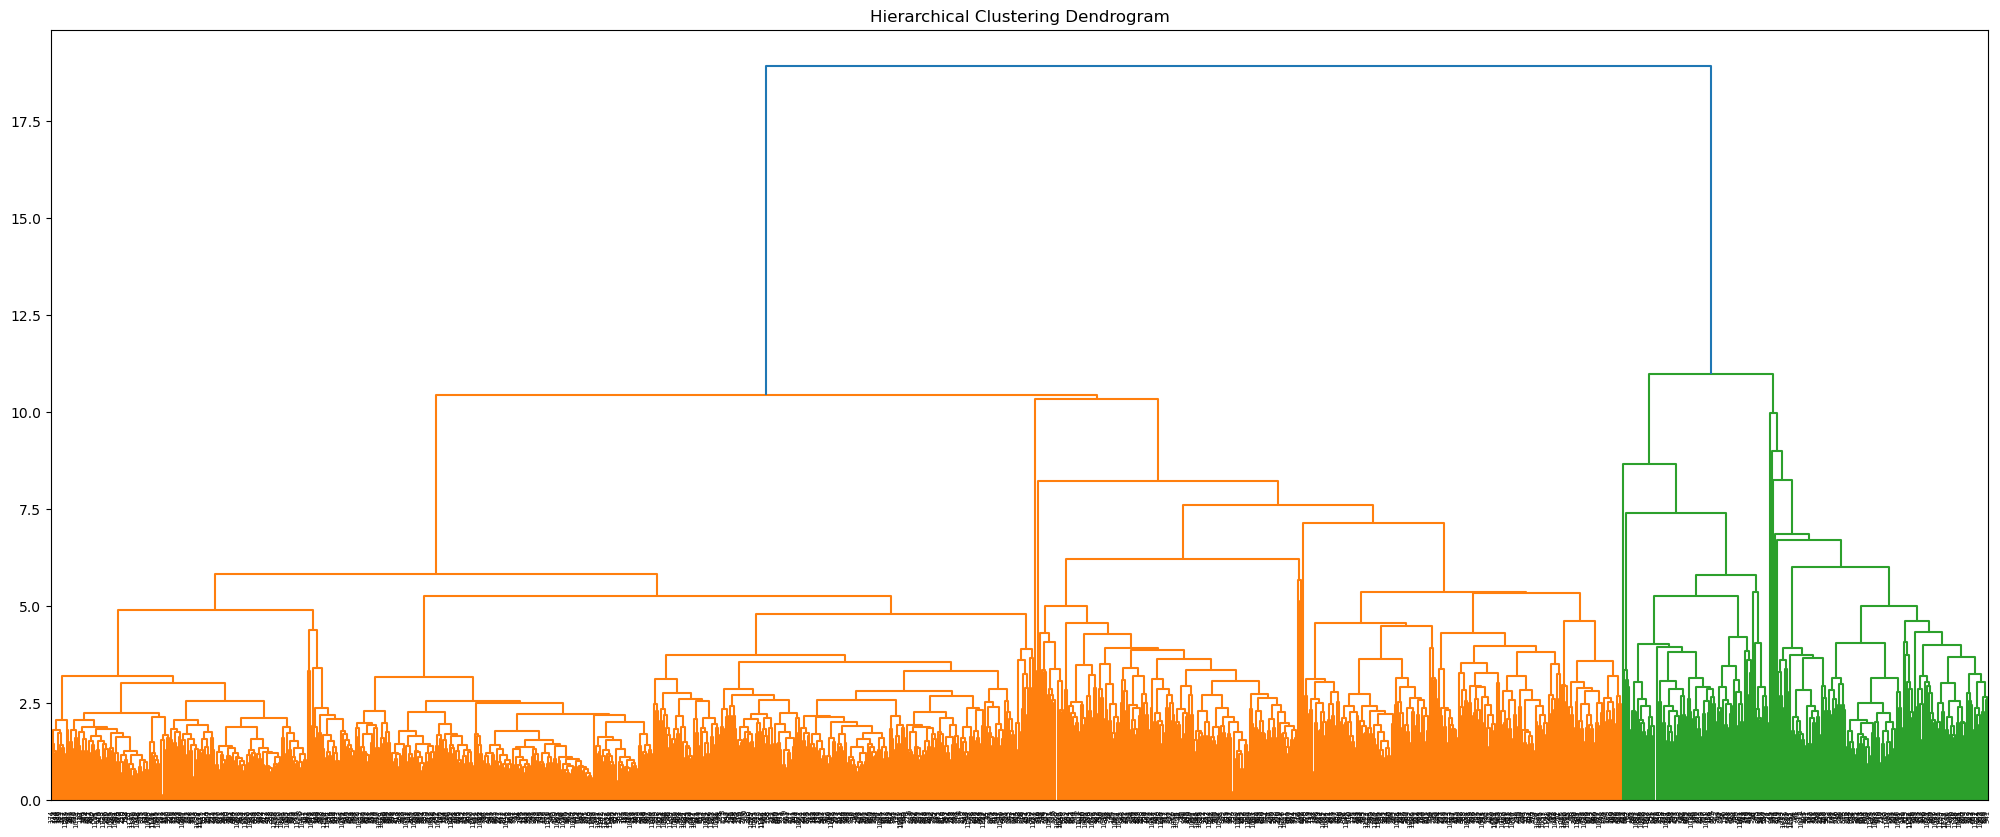

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib import pyplot as plt

# Perform hierarchical clustering
Z = linkage(cluster_df, 'ward', metric='euclidean')

# Plot the dendrogram
plt.figure(figsize=(25, 10))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

What do you think are reasonable choices for the number of clusters to select, based on the dendrogram? 

Based on the dendrogram, the reasonable choices for the number of clusters to selct are:
- 2 (height=11)
- 4 (height=10)
- 6 (height=9)
- 8-10 (height=8)

How about for the application? 

For this detailed analysis, 4 would be the appropriate number of clusters because it can provide meaningful groupings to see stock behavior without being too complex. 

### b.iii) Extract Cluster Assignments

In [16]:
from scipy.cluster.hierarchy import fcluster

# Set num of clusters
num_cluster = 4

# Perform hierarchical clustering
clusters = fcluster(Z, num_cluster, criterion='maxclust')

# add cluster column to nasdaq_df
nasdaq_df['Cluster'] = clusters

In [17]:
# Describe each cluster by:
# - Num of observations in the cluster 
# - Industry of the companies in the cluster
# - Subindustry of the companies in the cluster

cluster_description = nasdaq_df.groupby('Cluster').agg({
    'StockSymbol': 'count',
    'Industry': 'first',
    'SubIndustry': 'first'
})

cluster_description

,StockSymbol,Industry,SubIndustry
Cluster,,,
1,588,Industrial Goods,General Building Materials
2,351,Healthcare,Diagnostic Substances
3,88,Technology,Application Software
4,131,Consumer Goods,Electronic Equipment


### b.iv) Feb 2000 and Mar 2000 Analysis 

Feb 2000 Analysis:

In [48]:
# Get Feb 2000
feb_2000 = nasdaq_df[['StockSymbol', 'Industry', 'SubIndustry', 'Ret2000.02', 'Cluster']]

# Get Feb 2000 for each cluster
feb_2000_cluster = feb_2000.groupby('Cluster')['Ret2000.02'].mean()
feb_2000_cluster


Cluster
1   -0.023660
2    0.113993
3    1.038105
4    0.197151
Name: Ret2000.02, dtype: float64

In Feb 2000, cluster 1 has negative average returns, while the rest are positive. 

Mar 2000 Analysis:

In [49]:
# Get Mar 2000
mar_2000 = nasdaq_df[['StockSymbol', 'Industry', 'SubIndustry', 'Ret2000.03', 'Cluster']]

# Get Mar 2000 for each cluster
mar_2000_cluster = mar_2000.groupby('Cluster')['Ret2000.03'].mean()
mar_2000_cluster

Cluster
1    0.011428
2   -0.002455
3   -0.259350
4   -0.052053
Name: Ret2000.03, dtype: float64

In Mar 2000, cluster 1 has positive average returns, while the rest are negative. 

### b.v) K-Means Clustering

In [57]:
from sklearn.cluster import KMeans

# Prepare df for clustering
cluster_df = nasdaq_df.drop(columns=['StockSymbol', 'Industry', 'SubIndustry'])
cluster_df

# Perform KMeans clustering
kmeans = KMeans(n_clusters=num_cluster)
kmeans.fit(cluster_df)

KMeans(n_clusters=4)

In [58]:
# Get cluster for each observation
k_means_cluster = kmeans.predict(cluster_df)
k_means_cluster

array([1, 2, 0, ..., 3, 2, 1], dtype=int32)

In [59]:
# Add KMeansCluster column to nasdaq_df
nasdaq_df['KMeansCluster'] = k_means_cluster

In [60]:
# Extract KMeansCluster Assignments
kmeans_cluster_description = nasdaq_df.groupby('KMeansCluster').agg({
    'StockSymbol': 'count',
    'Industry': 'first',
    'SubIndustry': 'first'
})

kmeans_cluster_description

,StockSymbol,Industry,SubIndustry
KMeansCluster,,,
0,220,Healthcare,Diagnostic Substances
1,586,Industrial Goods,General Building Materials
2,219,Consumer Goods,Electronic Equipment
3,133,Basic Materials,Oil & Gas Equipment & Services


In [61]:
cluster_description

,StockSymbol,Industry,SubIndustry
Cluster,,,
1,588,Industrial Goods,General Building Materials
2,351,Healthcare,Diagnostic Substances
3,88,Technology,Application Software
4,131,Consumer Goods,Electronic Equipment


Comparing both cluster models:
- Both show significant grouping of stocks in Industrial Goods, Healthcare, and Consumer Goods industries. Except for Basic Materials and Technology Industry showing only on KMeans Cluster Model and Hierarchical Cluster Model respectively. 
- K-means cluster model clusters more evenly distributed in the individual clusters compared to Hierarchical cluster model, which shows more variability. 

## c) Proposition of Stock Portfolio

The strategy to pick stocks for a portfolio is to choose one from each cluster. This ensures diversity.

### Hierarchical Clustering Stock Portfolio

In [62]:
h_cluster_portfolio = nasdaq_df.groupby('Cluster').agg({
    'StockSymbol': 'first',
    'Industry': 'first',
    'SubIndustry': 'first', 
    'Ret2000.02': 'mean'
})

h_cluster_portfolio

,StockSymbol,Industry,SubIndustry,Ret2000.02
Cluster,,,,
1,AAON,Industrial Goods,General Building Materials,-0.023660
2,ABAX,Healthcare,Diagnostic Substances,0.113993
3,ACCL,Technology,Application Software,1.038105
4,AAPL,Consumer Goods,Electronic Equipment,0.197151


The above is the stocks propsition because it ensures diversity!

### KMeans Clustering Stock Portfolio

In [64]:
kmeans_cluster_portfolio = nasdaq_df.groupby('KMeansCluster').agg({
    'StockSymbol': 'first',
    'Industry': 'first',
    'SubIndustry': 'first',
    'Ret2000.02': 'mean'
})

kmeans_cluster_portfolio

,StockSymbol,Industry,SubIndustry,Ret2000.02
KMeansCluster,,,,
0,ABAX,Healthcare,Diagnostic Substances,0.184065
1,AAON,Industrial Goods,General Building Materials,-0.023827
2,AAPL,Consumer Goods,Electronic Equipment,0.535068
3,ACGY,Basic Materials,Oil & Gas Equipment & Services,-0.003247


The above is the stocks proposition because it ensures diversity!